In [9]:
from __future__ import annotations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style='whitegrid', context='notebook')

In [3]:
color_1 = [40, 120, 60]
color_2 = [60, 50, 90]

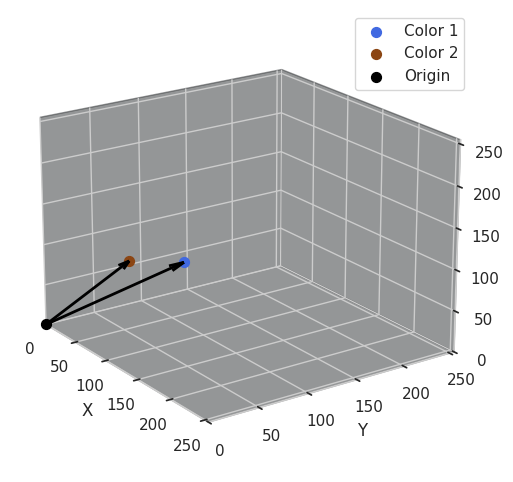

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    xs=color_1[0],
    ys=color_1[1],
    zs=color_1[2],
    label="Color 1",
    color="royalblue",
    s=50,
)

ax.scatter(
    xs=color_2[0],
    ys=color_2[1],
    zs=color_2[2],
    label="Color 2",
    color="saddlebrown",
    s=50,
)

ax.scatter(
    xs=0,
    ys=0,
    zs=0,
    label="Origin",
    color="black",
    s=50,
)

ax.quiver(
    0, 0, 0,
    color_1[0], color_1[1], color_1[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_2[0], color_2[1], color_2[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=20, azim=-35, roll=0)

ax.legend()

plt.show()

## Manhattan distance

In [5]:
L1 = [color_1[i] - color_2[i] for i in range(len(color_1))]
L1 = np.abs(L1).sum()

print(L1)

120


## Euclidean distance

In [6]:
L2 = [(color_1[i] - color_2[i]) ** 2 for i in range(len(color_1))]
L2 = np.sqrt(np.array(object=L2).sum())

print(L2)

78.74007874011811


## Cosine similarity

In [10]:
a = np.array(color_1)
b = np.array(color_2)
cosine = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(cosine)

0.8271930531781648


## Dot product

In [12]:
dot = np.array(object=[color_1[i] * color_2[i] for i in range(len(color_1))]).sum()

print(dot)

13800


In [13]:
color_1 = [40, 120, 60]
color_2 = [60, 50, 90]
color_3 = [40, 100, 70]

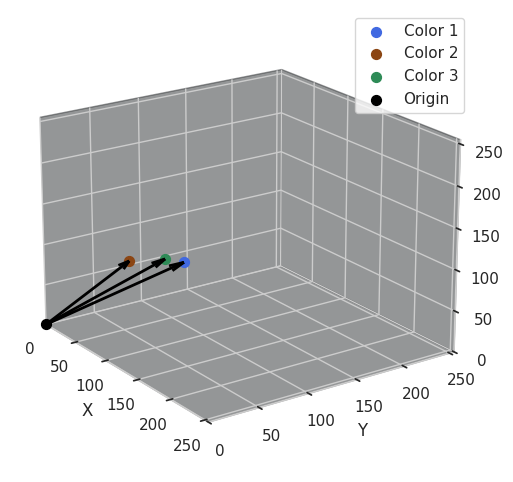

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    xs=color_1[0],
    ys=color_1[1],
    zs=color_1[2],
    label="Color 1",
    color="royalblue",
    s=50,
)

ax.scatter(
    xs=color_2[0],
    ys=color_2[1],
    zs=color_2[2],
    label="Color 2",
    color="saddlebrown",
    s=50,
)

ax.scatter(
    xs=color_3[0],
    ys=color_3[1],
    zs=color_3[2],
    label="Color 3",
    color="seagreen",
    s=50,
)

ax.scatter(
    xs=0,
    ys=0,
    zs=0,
    label="Origin",
    color="black",
    s=50,
)

ax.quiver(
    0, 0, 0,
    color_1[0], color_1[1], color_1[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_2[0], color_2[1], color_2[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.quiver(
    0, 0, 0,
    color_3[0], color_3[1], color_3[2],
    color="black",
    arrow_length_ratio=0.1,
    linewidth=2,
)

ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=20, azim=-35, roll=0)

ax.legend()

plt.show()

In [15]:
import json
import requests
from getpass import getpass
import os

In [16]:
os.environ['OPENAI_API_KEY'] = getpass('Provide OPEN_API_KEY')

In [17]:
response = requests.get(
    url="https://raw.githubusercontent.com/weaviate-tutorials/quickstart/main/data/jeopardy_tiny.json"
)

data = json.loads(s=response.text)

In [18]:
print(type(data), len(data))
print(json.dumps(obj=data[0], indent=2))

<class 'list'> 10
{
  "Category": "SCIENCE",
  "Question": "This organ removes excess glucose from the blood & stores it as glycogen",
  "Answer": "Liver"
}


In [19]:
def json_print(data):
    print(json.dumps(data, indent=2))

In [20]:
json_print(data)

[
  {
    "Category": "SCIENCE",
    "Question": "This organ removes excess glucose from the blood & stores it as glycogen",
    "Answer": "Liver"
  },
  {
    "Category": "ANIMALS",
    "Question": "It's the only living mammal in the order Proboseidea",
    "Answer": "Elephant"
  },
  {
    "Category": "ANIMALS",
    "Question": "The gavial looks very much like a crocodile except for this bodily feature",
    "Answer": "the nose or snout"
  },
  {
    "Category": "ANIMALS",
    "Question": "Weighing around a ton, the eland is the largest species of this animal in Africa",
    "Answer": "Antelope"
  },
  {
    "Category": "ANIMALS",
    "Question": "Heaviest of all poisonous snakes is this North American rattlesnake",
    "Answer": "the diamondback rattler"
  },
  {
    "Category": "SCIENCE",
    "Question": "2000 news: the Gunnison sage grouse isn't just another northern sage grouse, but a new one of this classification",
    "Answer": "species"
  },
  {
    "Category": "SCIENCE",
   

In [23]:
import os
import weaviate
from weaviate.embedded import EmbeddedOptions

In [26]:
def load_tiny_joepardy():
    url="https://raw.githubusercontent.com/weaviate-tutorials/quickstart/main/data/jeopardy_tiny.json"
    return requests.get(url).json()

In [28]:
def load_joepardy_1k():
    url="https://raw.githubusercontent.com/weaviate-tutorials/intro-workshop/main/data/jeopardy_1k.json"
    return requests.get(url).json()

In [29]:
def connect_embeded():
    if 'OPENAI_API_KEY' not in os.environ:
        raise ValueError('Set OPENAI_API_KE?Y before running this notebook')
    return weaviate.connect_to_embedded(
        headers={"X-OpenAI-Api-Key": os.environ['OPENAI_API_KEY']},
        environment_variables={
            'ENABLE_MODULES': 'text2vec-openai,'
        }
    )